In [76]:
!pip install pyspark --quiet
print('PySpark installation complete!')

PySpark installation complete!


In [77]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as f
from pyspark.sql.functions import year,month,to_date,col,round as spark_round

import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

spark = SparkSession.builder \
        .appName('Day4_BigData_Sales') \
        .config('spark.sql.adaptive.enabled', 'true') \
        .getOrCreate()
print(f'spark version : {spark.version}')
print(f'Spark Session: ACTIVE')
print(f'Application : {spark.conf.get("spark.app.name")}')


spark version : 4.0.2
Spark Session: ACTIVE
Application : Day4_BigData_Sales


In [78]:
csv_file_path = '/content/drive/MyDrive/Internship/large_sales_data.csv'
df_sales = spark.read.csv(csv_file_path, header=True, inferSchema=True)


In [79]:
df_bronze= spark.read \
          .option('header', 'true') \
          .option('inferSchema', 'true') \
          .csv('/content/drive/MyDrive/Internship/large_sales_data.csv')
print(f'=== Bronze Layer -- Raw Data===')
print(f'Rows : {df_bronze.count()}')
print(f'Columns : {len(df_bronze.columns)}')
print(f'Names : {df_bronze.columns}')
print()

df_bronze.printSchema()

=== Bronze Layer -- Raw Data===
Rows : 5000
Columns : 13
Names : ['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [80]:
print(f'Frist 5 rows :')
df_bronze.show(5, truncate=False)

print(f'\nBasic statistics for numeric columns: ')
df_bronze.select('quantity','unit_price','revenue').describe().show()


Frist 5 rows :
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi K

In [81]:
from os.path import isfile
df_bronze.write \
        .mode('overwrite') \
        .parquet('sales_bronze.parquet')

print('Bronze Parquet saved: sales_bronze.praquet')

import os
def get_dir_size(dir_path):
    if os.path.isfile(dir_path):
        return os.path.getsize(dir_path) / 1024
    total = 0
    for dirpath,dirnames,filenames in os.walk(dir_path):
        for f in filenames:
            total += os.path.getsize(os.path.join(dirpath, f))
    return total / 1024


csv_size = get_dir_size(csv_file_path)
parquet_size = get_dir_size('sales_bronze.parquet')
reduction = (1-parquet_size/csv_size)*100
print(f'CSV File Size: {csv_size:.2f} KB')
print(f'Parquet File Size: {parquet_size:.2f} KB')
print(f'Reduction in Size: {reduction:.1f}% smaller')
print(f'\nAt 1 TB scale: CSV=1000 GB -> parquet = {1000*(1-reduction/100):.0f}GB')

Bronze Parquet saved: sales_bronze.praquet
CSV File Size: 529.31 KB
Parquet File Size: 55.10 KB
Reduction in Size: 89.6% smaller

At 1 TB scale: CSV=1000 GB -> parquet = 104GB


In [82]:
df_silver = df_bronze \
           .dropDuplicates() \
           .dropna(subset=['order_id','product','revenue'])

df_silver = df_silver.withColumn(
    'order_date',
    to_date(col('order_date'), 'yyyy-MM-dd')
)

df_silver= df_silver \
          .withColumn('order_year', year(col('order_date'))) \
          .withColumn('order_month', month(col('order_date')))

df_silver = df_silver.withColumn(
    'revenue_category',
    f.when(col('revenue') > 40000, 'High')
    .when(col('revenue') > 10000, 'Medium')
    .otherwise('Low')
)


print(f'Silver Layer Rows : {df_silver.count()}')
print('New columns added: order_year, order_month, revenue_category')
df_silver.select('product','revenue','order_year','order_month','revenue_category').show(5)

Silver Layer Rows : 5000
New columns added: order_year, order_month, revenue_category
+--------+-------+----------+-----------+----------------+
| product|revenue|order_year|order_month|revenue_category|
+--------+-------+----------+-----------+----------------+
|Keyboard|  13200|      2023|          2|          Medium|
|  Webcam|  17500|      2023|          1|          Medium|
| Speaker|  58500|      2023|          4|            High|
|Keyboard|   9600|      2023|         12|             Low|
|  Laptop| 180000|      2023|          8|            High|
+--------+-------+----------+-----------+----------------+
only showing top 5 rows


In [83]:
df_silver.write \
         .mode('overwrite') \
         .parquet('sales_silver.parquet')

print('Silver Parquet saved: sales_silver.praquet')
print(f'Silver Size: {get_dir_size("sales_silver.parquet"):.1f} KB')

df_verify = spark.read.parquet('sales_silver.parquet')
print(f'Verify Silver Size')
print(f'Read-back rows: {df_verify.count()} (should match silver count)')
df_verify.printSchema()

Silver Parquet saved: sales_silver.praquet
Silver Size: 59.8 KB
Verify Silver Size
Read-back rows: 5000 (should match silver count)
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



In [84]:
top_products = df_silver \
              .groupBy('product') \
              .agg(
                  f.sum('revenue').alias('total_revenue'),
                  f.count('order_id').alias('order_count'),
                  f.avg('revenue').alias('avg_revenue')
              ) \
              .orderBy('total_revenue', ascending = False)\
              .limit(5)

print("=== Top 5 Products by Average Revenue ===")
top_products.show(truncate=False)


=== Top 5 Products by Average Revenue ===
+-------+-------------+-----------+------------------+
|product|total_revenue|order_count|avg_revenue       |
+-------+-------------+-----------+------------------+
|Laptop |182700000    |502        |363944.22310756973|
|Tablet |135104000    |532        |253954.8872180451 |
|Monitor|82126000     |481        |170740.12474012474|
|Printer|44544000     |488        |91278.68852459016 |
|Speaker|16317000     |470        |34717.02127659575 |
+-------+-------------+-----------+------------------+



In [85]:
region_revenue= df_silver \
               .groupBy('region') \
               .agg(
                   f.sum('revenue').alias('total_revenue'),
                   f.count('order_id').alias('order_count'),
                   f.countDistinct('customer_name').alias('customer_count')
               ) \
               .orderBy('total_revenue', ascending = False)

print("=== Revenue by Region ===")
region_revenue.show(truncate=False)

=== Revenue by Region ===
+------+-------------+-----------+--------------+
|region|total_revenue|order_count|customer_count|
+------+-------------+-----------+--------------+
|West  |198275600    |2021       |15            |
|South |147145900    |1483       |15            |
|North |99878400     |995        |15            |
|East  |50547700     |501        |15            |
+------+-------------+-----------+--------------+



In [86]:
distinct_customers_by_region = df_silver \
        .groupBy('region') \
        .agg(
            f.collect_set('customer_name').alias('distinct_customer_names')
        ) \
        .orderBy('region', ascending = True)

print("=== Distinct Customers by Region ===")
distinct_customers_by_region.show(truncate=False)

=== Distinct Customers by Region ===
+------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|region|distinct_customer_names                                                                                                                                                                            |
+------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|East  |[Meera Joshi, Ananya Das, Kiran Kumar, Vikram Iyer, Pooja Gupta, Ramesh Kumar, Rahul Mishra, Divya Singh, Arjun Nair, Sneha Reddy, Priya Patel, Suresh Rao, Kavya Nambiar, Amit Verma, Tanvi Mehta]|
|North |[Meera Joshi, Ananya Das, Kiran Kumar, Vikram Iyer, Pooja Gupta, Ramesh Kumar, Rahul Mishra, Divya Singh, Arjun Nair, Sneha Reddy, Priy

In [87]:
m_r_trend = df_silver \
    .groupBy('order_month') \
    .agg(
        f.sum('revenue').alias('monthly_revenue'),
        f.count('order_id').alias('monthly_orders')
    ) \
    .orderBy('order_month')

print("=== Monthly Revenue Trend ===")
m_r_trend.show(truncate=False)

=== Monthly Revenue Trend ===
+-----------+---------------+--------------+
|order_month|monthly_revenue|monthly_orders|
+-----------+---------------+--------------+
|1          |41068200       |423           |
|2          |34485400       |375           |
|3          |40031200       |451           |
|4          |38857100       |390           |
|5          |39984500       |423           |
|6          |40707400       |390           |
|7          |42640700       |405           |
|8          |43718500       |418           |
|9          |37640200       |398           |
|10         |47839000       |479           |
|11         |44577100       |419           |
|12         |44298300       |429           |
+-----------+---------------+--------------+



In [88]:
m_r_trend_names = df_silver \
    .withColumn('month_name', f.date_format(f.col('order_date'), 'MMMM')) \
    .groupBy('order_month', 'month_name') \
    .agg(
        f.sum('revenue').alias('monthly_revenue'),
        f.count('order_id').alias('monthly_orders')
    ) \
    .orderBy('order_month') \
    .select('order_month', 'month_name', 'monthly_revenue', 'monthly_orders')

print("=== Monthly Revenue Trend with Month Names ===")
m_r_trend_names.show(truncate=False)

=== Monthly Revenue Trend with Month Names ===
+-----------+----------+---------------+--------------+
|order_month|month_name|monthly_revenue|monthly_orders|
+-----------+----------+---------------+--------------+
|1          |January   |41068200       |423           |
|2          |February  |34485400       |375           |
|3          |March     |40031200       |451           |
|4          |April     |38857100       |390           |
|5          |May       |39984500       |423           |
|6          |June      |40707400       |390           |
|7          |July      |42640700       |405           |
|8          |August    |43718500       |418           |
|9          |September |37640200       |398           |
|10         |October   |47839000       |479           |
|11         |November  |44577100       |419           |
|12         |December  |44298300       |429           |
+-----------+----------+---------------+--------------+



In [89]:
gold_region = region_revenue
gold_region.write.mode('overwrite').parquet('sales_gold_region.parquet')
print('Gold Parquet 1 saved: sales_gold_region.praquet')

gold_product = df_silver \
               .groupBy('product', 'category') \
               .agg(
                   f.sum('revenue').alias('total_revenue'),
                   f.count('order_id').alias('order_count'),
                   spark_round(f.avg('revenue'),2).alias('avg_revenue'),
                   f.max('revenue').alias('largest_order')
               ) \
               .orderBy('total_revenue', ascending = False)

gold_product.write.mode('overwrite').parquet('sales_gold_product.parquet')
print('Gold Parquet 2 saved: sales_gold_product.praquet')


gold_monthly = m_r_trend_names
gold_monthly.write.mode('overwrite').parquet('sales_gold_monthly.parquet')
print('Gold Parquet 3 saved: sales_gold_monthly.praquet')



Gold Parquet 1 saved: sales_gold_region.praquet
Gold Parquet 2 saved: sales_gold_product.praquet
Gold Parquet 3 saved: sales_gold_monthly.praquet


In [90]:
region_pd= spark.read.parquet('sales_gold_region.parquet').toPandas()
product_pd= spark.read.parquet('sales_gold_product.parquet').toPandas()
monthly_pd= spark.read.parquet('sales_gold_monthly.parquet').toPandas()

print('Gold tables converted to Pandas DataFrames')
print(f'   region  : {region_pd.shape}')
print(f'   product : {product_pd.shape}')
print(f'   monthly : {monthly_pd.shape}')

region_pd = region_pd.sort_values('total_revenue', ascending=False)
product_pd = product_pd.sort_values('total_revenue', ascending=False)
monthly_pd = monthly_pd.sort_values('month_name', ascending=True)

gold_monthly.show(5)
gold_product.show(5)
gold_region.show(5)

Gold tables converted to Pandas DataFrames
   region  : (4, 4)
   product : (10, 6)
   monthly : (12, 4)
+-----------+----------+---------------+--------------+
|order_month|month_name|monthly_revenue|monthly_orders|
+-----------+----------+---------------+--------------+
|          1|   January|       41068200|           423|
|          2|  February|       34485400|           375|
|          3|     March|       40031200|           451|
|          4|     April|       38857100|           390|
|          5|       May|       39984500|           423|
+-----------+----------+---------------+--------------+
only showing top 5 rows
+-------+-----------+-------------+-----------+-----------+-------------+
|product|   category|total_revenue|order_count|avg_revenue|largest_order|
+-------+-----------+-------------+-----------+-----------+-------------+
| Laptop|Electronics|    182700000|        502|  363944.22|       675000|
| Tablet|Electronics|    135104000|        532|  253954.89|       48000

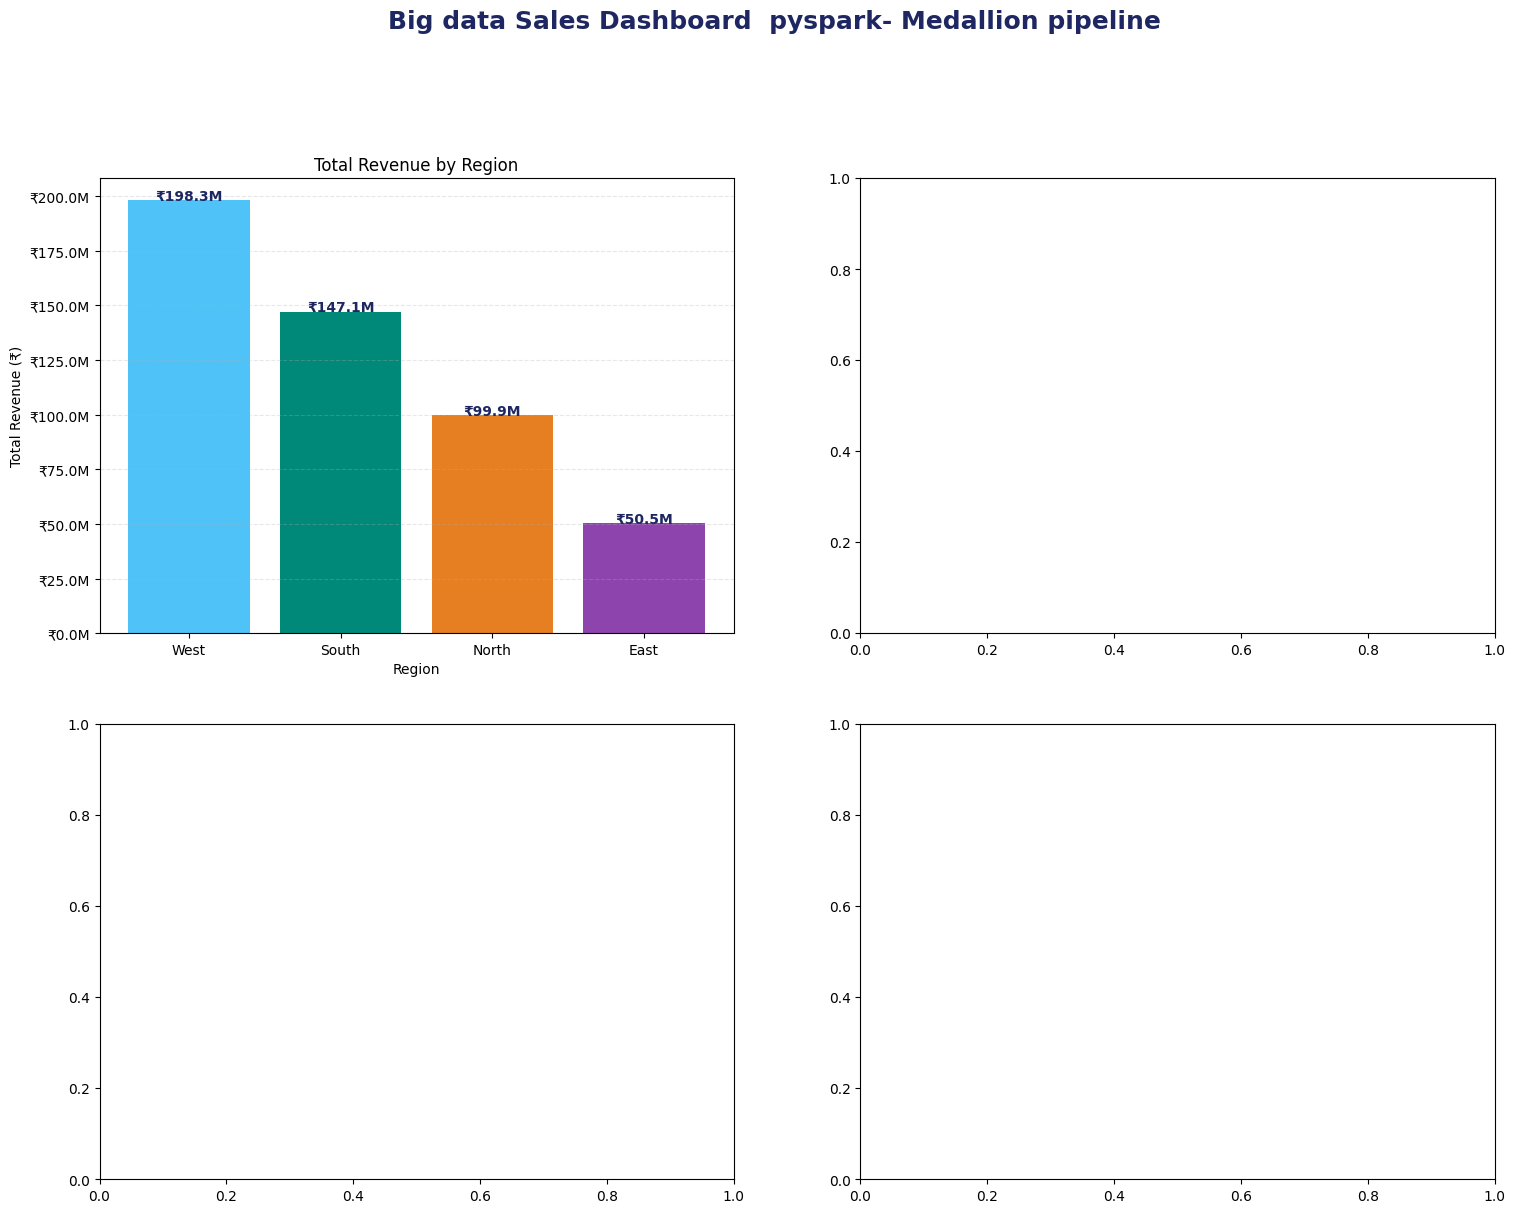

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Big data Sales Dashboard  pyspark- Medallion pipeline', fontsize=18,fontweight='bold',color='#1E2761',y=1.01)

colors4 = ['#4FC3F7','#008978','#E67E22','#8E44AD','#E74C3C']

ax1 = axes[0,0]

bars1=ax1.bar(region_pd['region'], region_pd['total_revenue'] / 1_000_000, color=colors4[:len(region_pd['region'])])

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'₹{bar.get_height():.1f}M', ha='center', fontsize=10,fontweight='bold',color='#1E2761')


axes[0, 0].set_title('Total Revenue by Region')
axes[0, 0].set_xlabel('Region')
axes[0, 0].set_ylabel('Total Revenue (₹)')
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x:.1f}M'))



ax1.grid(axis='y', linestyle='--', alpha=0.3)

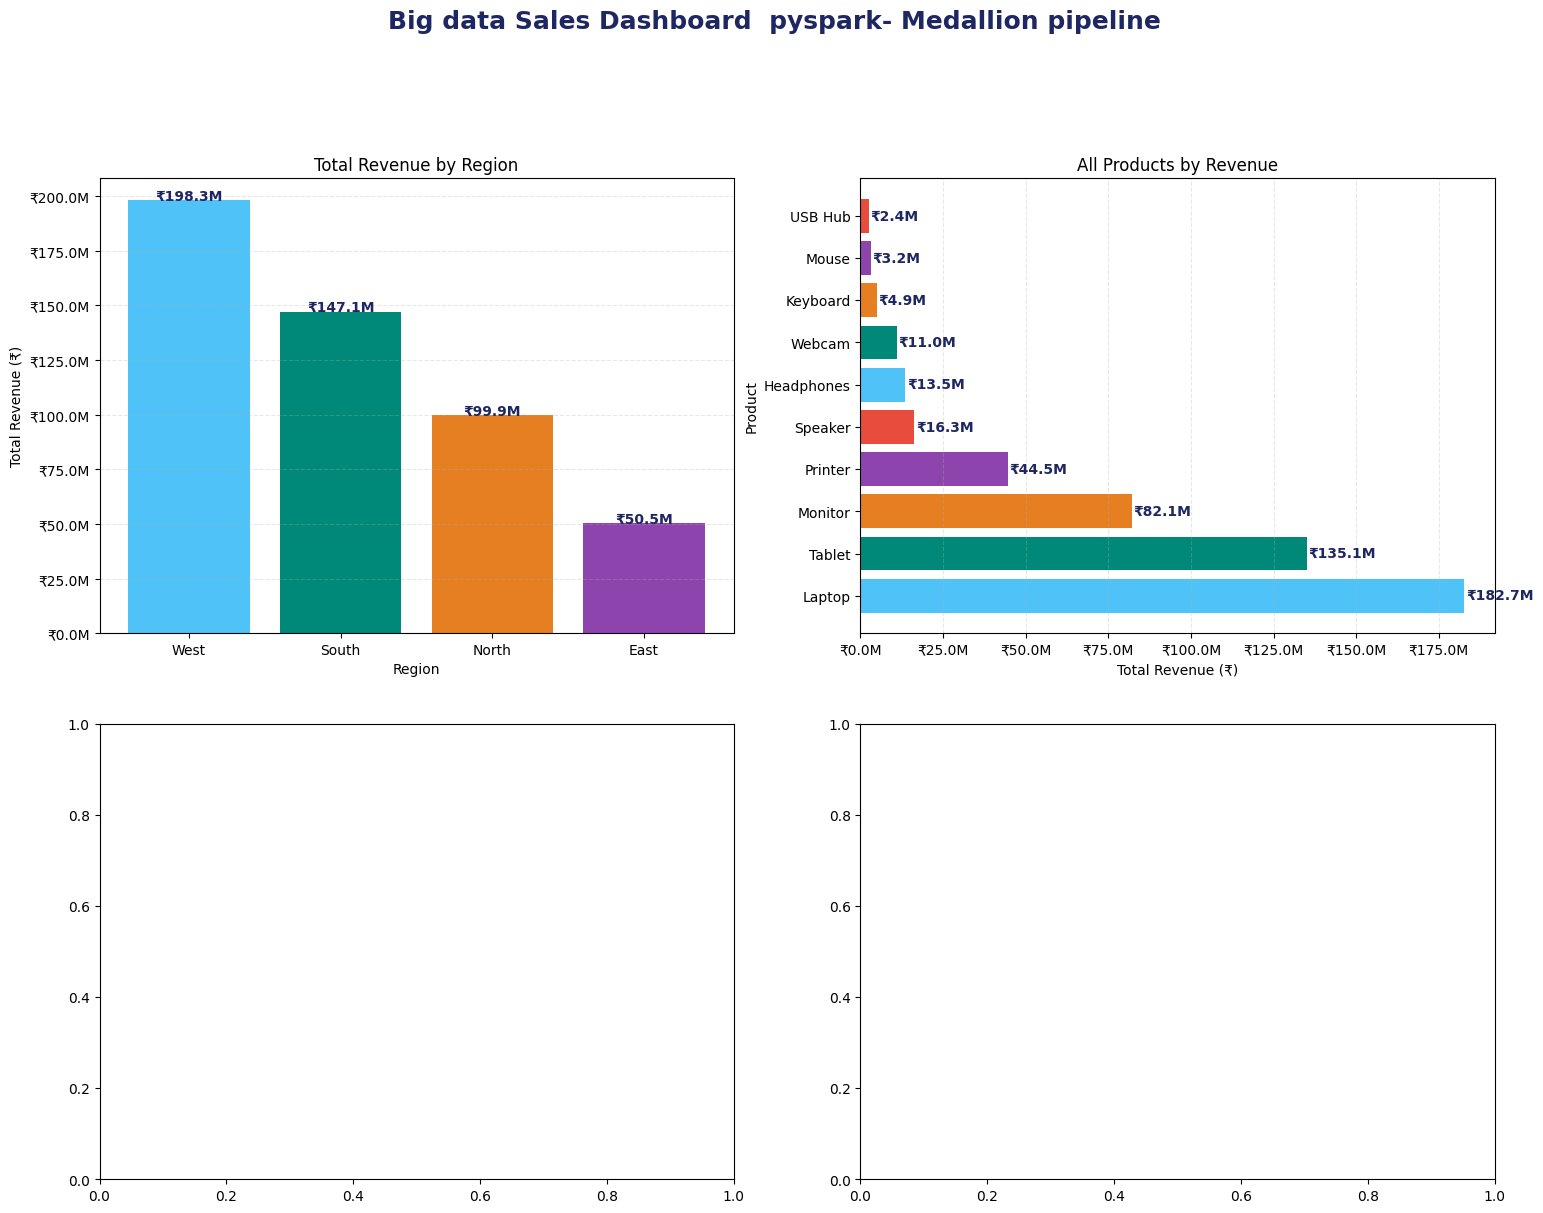

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Big data Sales Dashboard  pyspark- Medallion pipeline', fontsize=18,fontweight='bold',color='#1E2761',y=1.01)

colors4 = ['#4FC3F7','#008978','#E67E22','#8E44AD','#E74C3C']

ax1 = axes[0,0]

bars1=ax1.bar(region_pd['region'], region_pd['total_revenue'] / 1_000_000, color=colors4[:len(region_pd['region'])])

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'₹{bar.get_height():.1f}M', ha='center', fontsize=10,fontweight='bold',color='#1E2761')


axes[0, 0].set_title('Total Revenue by Region')
axes[0, 0].set_xlabel('Region')
axes[0, 0].set_ylabel('Total Revenue (₹)')
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x:.1f}M'))



ax1.grid(axis='y', linestyle='--', alpha=0.3)


ax2 = axes[0,1]


all_products_pd = product_pd

num_products = len(all_products_pd['product'])
current_colors = [colors4[i % len(colors4)] for i in range(num_products)]

bars2=ax2.barh(all_products_pd['product'], all_products_pd['total_revenue'] / 1_000_000, color=current_colors)

for bar in bars2:
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'₹{bar.get_width():.1f}M', ha='left', va='center', fontsize=10,fontweight='bold',color='#1E2761')



axes[0, 1].set_title('All Products by Revenue') # Updated title
axes[0, 1].set_xlabel('Total Revenue (₹)')
axes[0, 1].set_ylabel('Product')
axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x:.1f}M'))



ax2.grid(axis='x', linestyle='--', alpha=0.3)

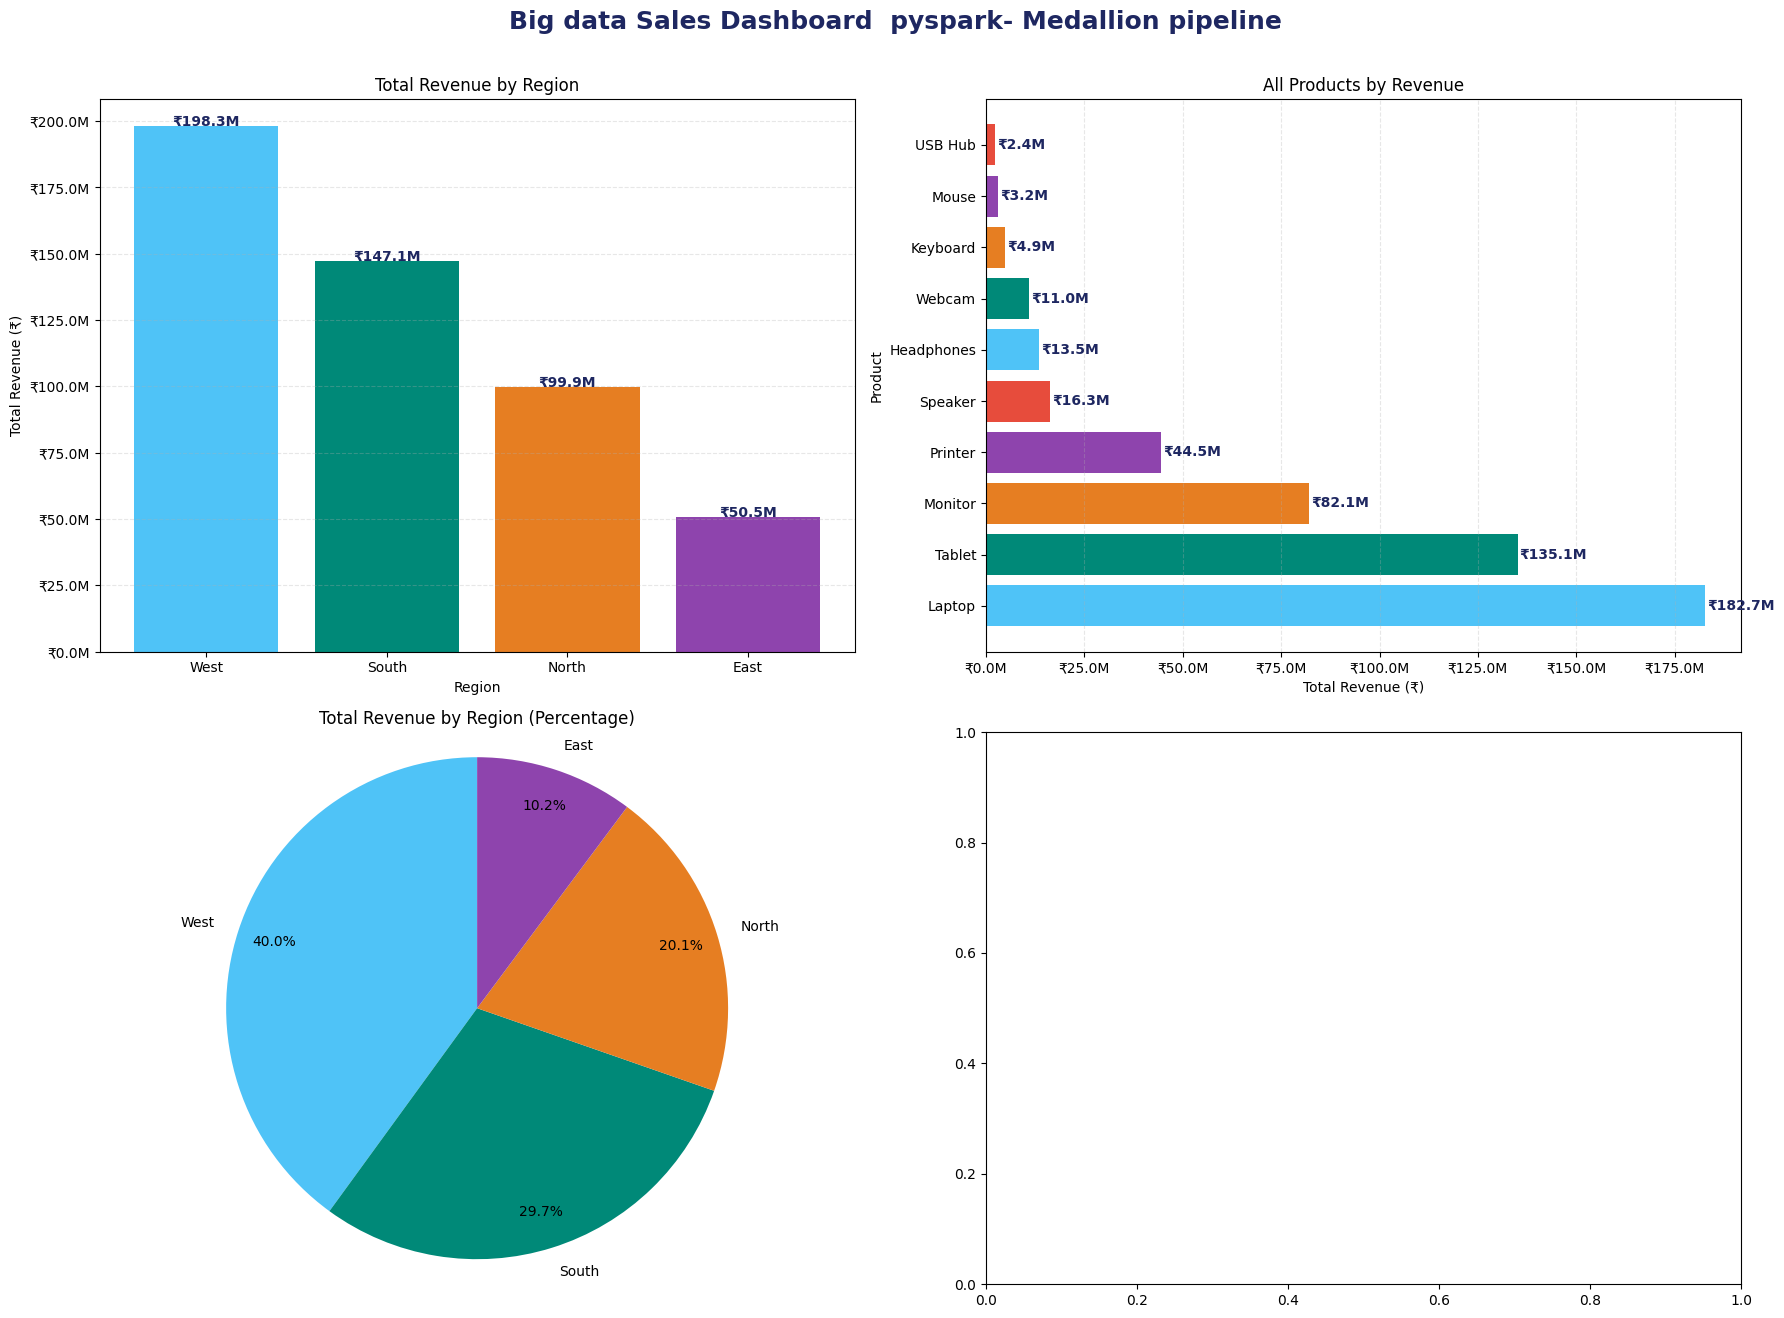

In [94]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Big data Sales Dashboard  pyspark- Medallion pipeline', fontsize=18,fontweight='bold',color='#1E2761',y=1.01)

colors4 = ['#4FC3F7','#008978','#E67E22','#8E44AD','#E74C3C']

ax1 = axes[0,0]

bars1=ax1.bar(region_pd['region'], region_pd['total_revenue'] / 1_000_000, color=colors4[:len(region_pd['region'])])

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'₹{bar.get_height():.1f}M', ha='center', fontsize=10,fontweight='bold',color='#1E2761')


axes[0, 0].set_title('Total Revenue by Region')
axes[0, 0].set_xlabel('Region')
axes[0, 0].set_ylabel('Total Revenue (₹)')
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x:.1f}M'))



ax1.grid(axis='y', linestyle='--', alpha=0.3)


ax2 = axes[0,1]


all_products_pd = product_pd

num_products = len(all_products_pd['product'])
current_colors = [colors4[i % len(colors4)] for i in range(num_products)]

bars2=ax2.barh(all_products_pd['product'], all_products_pd['total_revenue'] / 1_000_000, color=current_colors)

for bar in bars2:
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'₹{bar.get_width():.1f}M', ha='left', va='center', fontsize=10,fontweight='bold',color='#1E2761')



axes[0, 1].set_title('All Products by Revenue')
axes[0, 1].set_xlabel('Total Revenue (₹)')
axes[0, 1].set_ylabel('Product')
axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x:.1f}M'))



ax2.grid(axis='x', linestyle='--', alpha=0.3)


ax3 = axes[1,0]


explode = [0.0] * len(region_pd['region'])
ax3.pie(region_pd['total_revenue'], labels=region_pd['region'], autopct='%1.1f%%', startangle=90, colors=colors4[:len(region_pd['region'])], explode=explode, pctdistance=0.85)
ax3.set_title('Total Revenue by Region (Percentage)')
ax3.axis('equal')

plt.tight_layout()

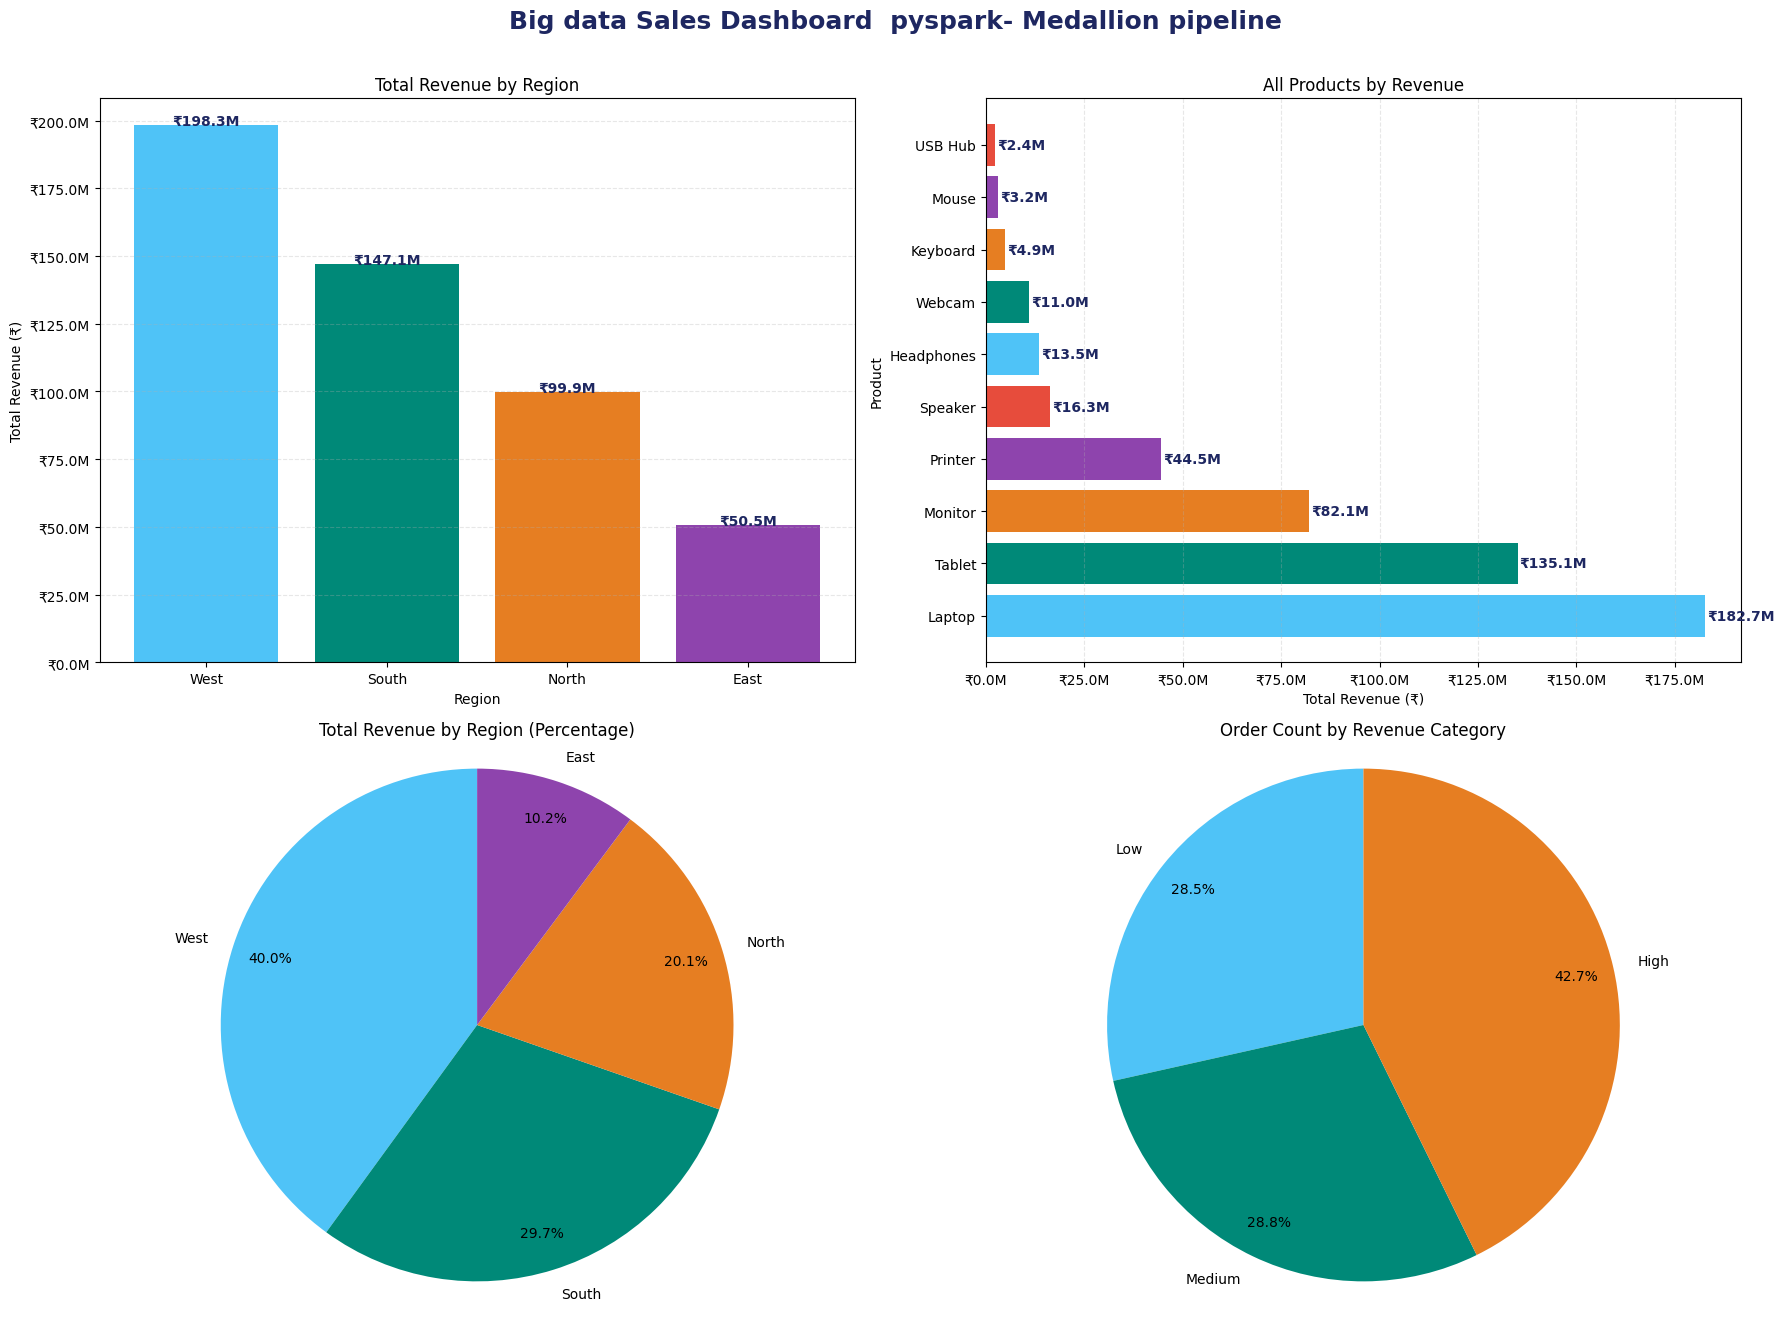

In [97]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Big data Sales Dashboard  pyspark- Medallion pipeline', fontsize=18,fontweight='bold',color='#1E2761',y=1.01)

colors4 = ['#4FC3F7','#008978','#E67E22','#8E44AD','#E74C3C']

ax1 = axes[0,0]

bars1=ax1.bar(region_pd['region'], region_pd['total_revenue'] / 1_000_000, color=colors4[:len(region_pd['region'])])

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'₹{bar.get_height():.1f}M', ha='center', fontsize=10,fontweight='bold',color='#1E2761')


axes[0, 0].set_title('Total Revenue by Region')
axes[0, 0].set_xlabel('Region')
axes[0, 0].set_ylabel('Total Revenue (₹)')
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x:.1f}M'))



ax1.grid(axis='y', linestyle='--', alpha=0.3)


ax2 = axes[0,1]


all_products_pd = product_pd

num_products = len(all_products_pd['product'])
current_colors = [colors4[i % len(colors4)] for i in range(num_products)]

bars2=ax2.barh(all_products_pd['product'], all_products_pd['total_revenue'] / 1_000_000, color=current_colors)

for bar in bars2:
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'₹{bar.get_width():.1f}M', ha='left', va='center', fontsize=10,fontweight='bold',color='#1E2761')



axes[0, 1].set_title('All Products by Revenue')
axes[0, 1].set_xlabel('Total Revenue (₹)')
axes[0, 1].set_ylabel('Product')
axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x:.1f}M'))



ax2.grid(axis='x', linestyle='--', alpha=0.3)


ax3 = axes[1,0]


explode = [0.0] * len(region_pd['region'])
ax3.pie(region_pd['total_revenue'], labels=region_pd['region'], autopct='%1.1f%%', startangle=90, colors=colors4[:len(region_pd['region'])], explode=explode, pctdistance=0.85)
ax3.set_title('Total Revenue by Region (Percentage)')
ax3.axis('equal')


ax4 = axes[1,1]

order_category_agg = df_silver.groupBy('revenue_category').agg(f.count('order_id').alias('order_count'))
order_category_pd = order_category_agg.toPandas()


category_order = ['Low', 'Medium', 'High']
order_category_pd['revenue_category'] = pd.Categorical(order_category_pd['revenue_category'], categories=category_order, ordered=True)
order_category_pd = order_category_pd.sort_values('revenue_category')

explode_category = [0.0] * len(order_category_pd['revenue_category'])
ax4.pie(order_category_pd['order_count'], labels=order_category_pd['revenue_category'], autopct='%1.1f%%', startangle=90, colors=colors4[:len(order_category_pd['revenue_category'])], explode=explode_category, pctdistance=0.85)
ax4.set_title('Order Count by Revenue Category')
ax4.axis('equal')

plt.tight_layout()

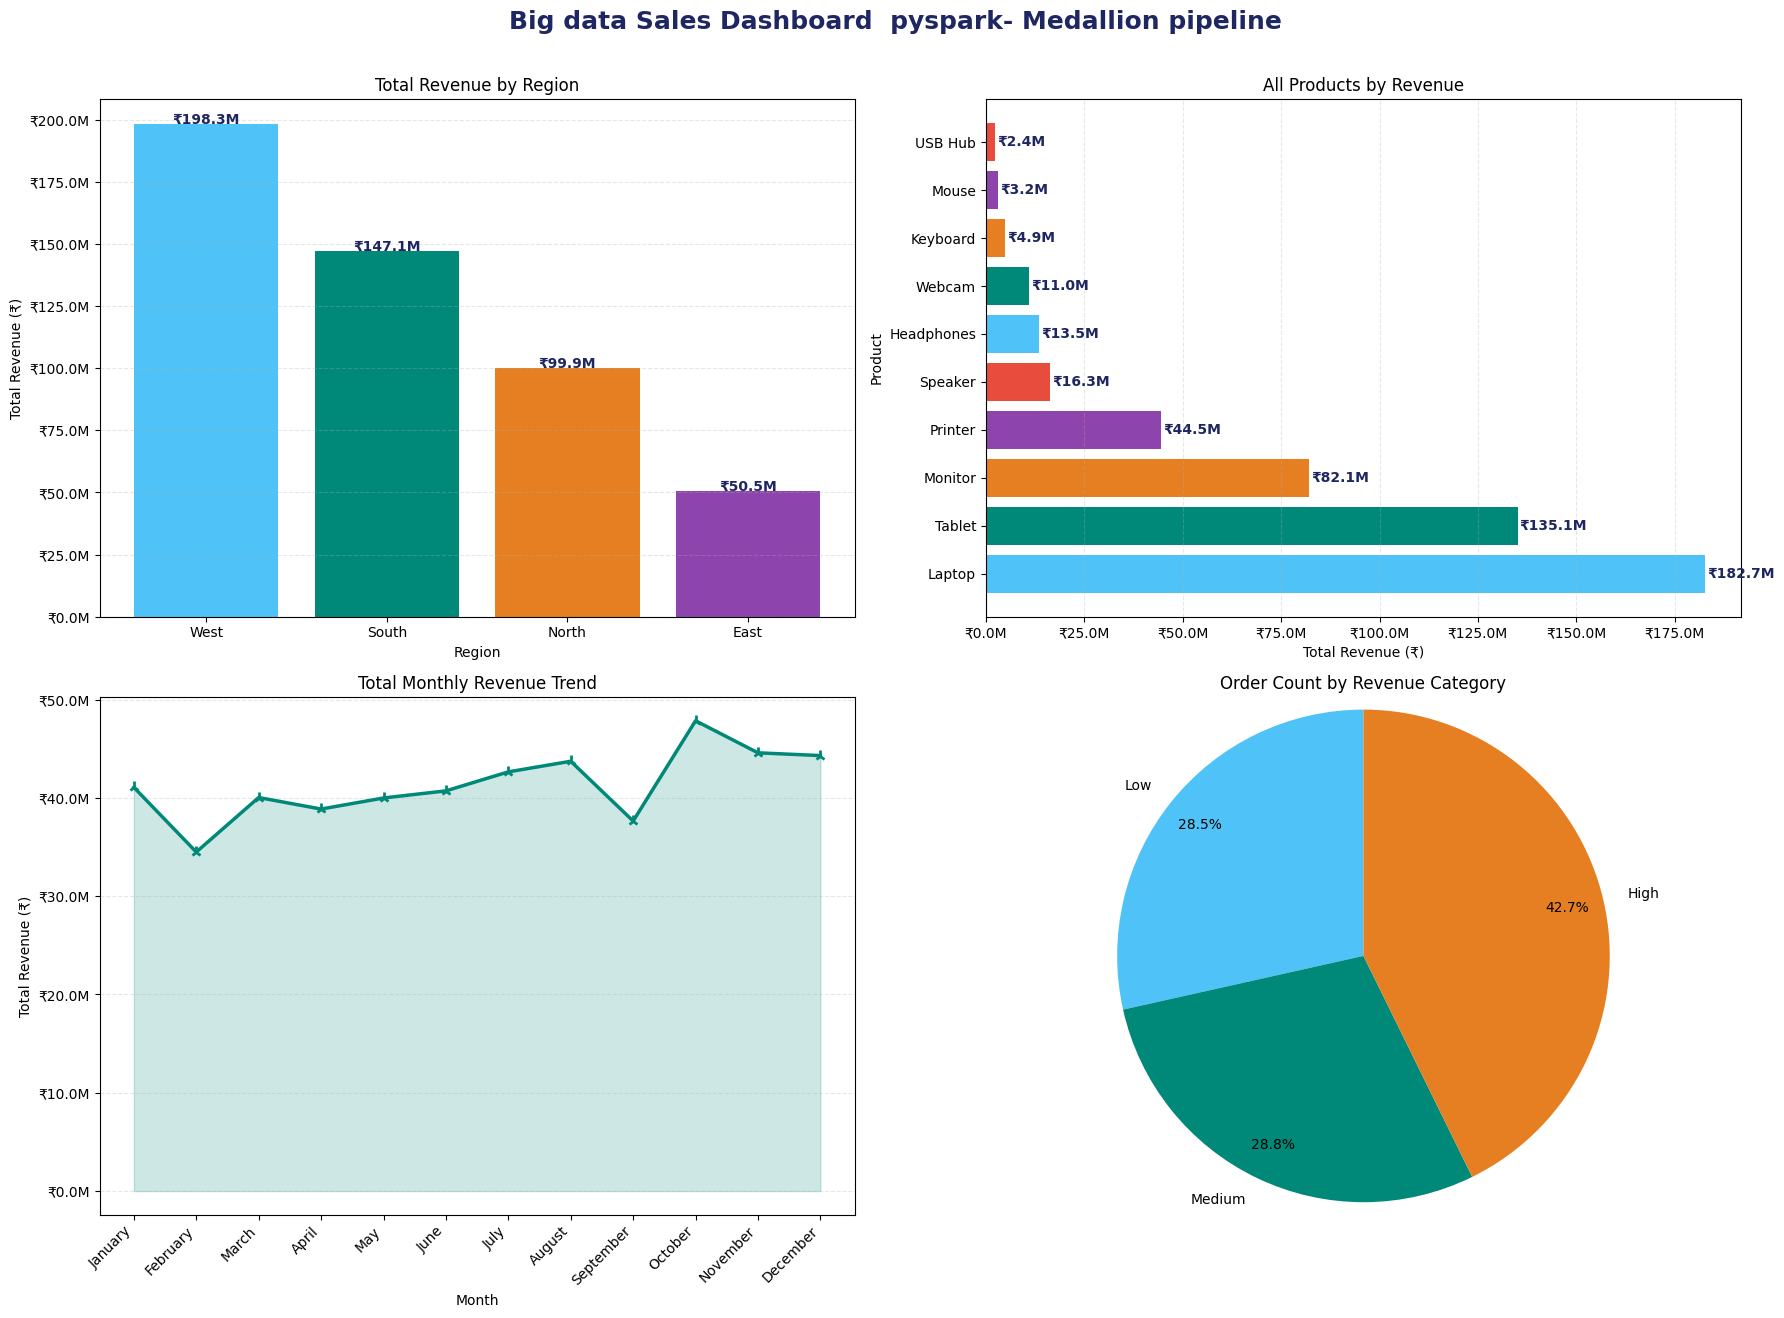

In [106]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Big data Sales Dashboard  pyspark- Medallion pipeline', fontsize=18,fontweight='bold',color='#1E2761',y=1.01)

colors4 = ['#4FC3F7','#008978','#E67E22','#8E44AD','#E74C3C']

ax1 = axes[0,0]

bars1=ax1.bar(region_pd['region'], region_pd['total_revenue'] / 1_000_000, color=colors4[:len(region_pd['region'])])

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'₹{bar.get_height():.1f}M', ha='center', fontsize=10,fontweight='bold',color='#1E2761')


axes[0, 0].set_title('Total Revenue by Region')
axes[0, 0].set_xlabel('Region')
axes[0, 0].set_ylabel('Total Revenue (₹)')
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x:.1f}M'))



ax1.grid(axis='y', linestyle='--', alpha=0.3)


ax2 = axes[0,1]


all_products_pd = product_pd

num_products = len(all_products_pd['product'])
current_colors = [colors4[i % len(colors4)] for i in range(num_products)]

bars2=ax2.barh(all_products_pd['product'], all_products_pd['total_revenue'] / 1_000_000, color=current_colors)

for bar in bars2:
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'₹{bar.get_width():.1f}M', ha='left', va='center', fontsize=10,fontweight='bold',color='#1E2761')



axes[0, 1].set_title('All Products by Revenue')
axes[0, 1].set_xlabel('Total Revenue (₹)')
axes[0, 1].set_ylabel('Product')
axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x:.1f}M'))



ax2.grid(axis='x', linestyle='--', alpha=0.3)


ax3 = axes[1,0]

monthly_pd_sorted = monthly_pd.sort_values('order_month')

ax3.plot(monthly_pd_sorted['month_name'], monthly_pd_sorted['monthly_revenue'] / 1_000_000, marker='o', linewidth=2.5, color='#008978',markersize=8,markerfacecolor='white',markeredgewidth=2)
ax3.fill_between(monthly_pd_sorted['month_name'], monthly_pd_sorted['monthly_revenue'] / 1_000_000, color='#008978', alpha=0.2)
ax3.set_title('Total Monthly Revenue Trend')
ax3.set_xlabel('Month')
ax3.set_ylabel('Total Revenue (₹)')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x:.1f}M'))
ax3.grid(axis='y', linestyle='--', alpha=0.3)


plt.setp(ax3.get_xticklabels(), rotation=45, ha="right")


ax4 = axes[1,1]

order_category_agg = df_silver.groupBy('revenue_category').agg(f.count('order_id').alias('order_count'))
order_category_pd = order_category_agg.toPandas()


category_order = ['Low', 'Medium', 'High']
order_category_pd['revenue_category'] = pd.Categorical(order_category_pd['revenue_category'], categories=category_order, ordered=True)
order_category_pd = order_category_pd.sort_values('revenue_category')

explode_category = [0.0] * len(order_category_pd['revenue_category'])
ax4.pie(order_category_pd['order_count'], labels=order_category_pd['revenue_category'], autopct='%1.1f%%', startangle=90, colors=colors4[:len(order_category_pd['revenue_category'])], explode=explode_category, pctdistance=0.85)
ax4.set_title('Order Count by Revenue Category')
ax4.axis('equal')

plt.tight_layout()